In [16]:
# ================================
# STEP 1: Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



In [17]:
# ================================
# STEP 2: Load and Explore Dataset
# ================================
fraud_data = pd.read_csv('fraud_sample_500.csv')

print(fraud_data.head())
fraud_data.info()
print(fraud_data.describe())

   step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   278   CASH_IN   330218.42   C632336343       20866.00       351084.42   
1    15   PAYMENT    11647.08  C1264712553       30370.00        18722.92   
2    10   CASH_IN   152264.21  C1746846248      106589.00       258853.21   
3   403  TRANSFER  1551760.63   C333676753           0.00            0.00   
4   206   CASH_IN    78172.30   C813403091     2921331.58      2999503.88   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0   C834976624       452419.57       122201.15        0               0  
1   M215391829            0.00            0.00        0               0  
2  C1607284477       201303.01        49038.80        0               0  
3  C1564353608      3198359.45      4750120.08        0               0  
4  C1091768874       415821.90       337649.60        0               0  
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):

In [18]:
# ================================
# STEP 3: Data Visualization
# ================================

# Count of columns by type
obj_cols = fraud_data.select_dtypes(include='str').columns
int_cols = fraud_data.select_dtypes(include='int').columns
float_cols = fraud_data.select_dtypes(include='float').columns
print("Text columns:", len(obj_cols))
print("Whole number columns:", len(int_cols))
print("Decimal columns:", len(float_cols))


Text columns: 3
Whole number columns: 3
Decimal columns: 5


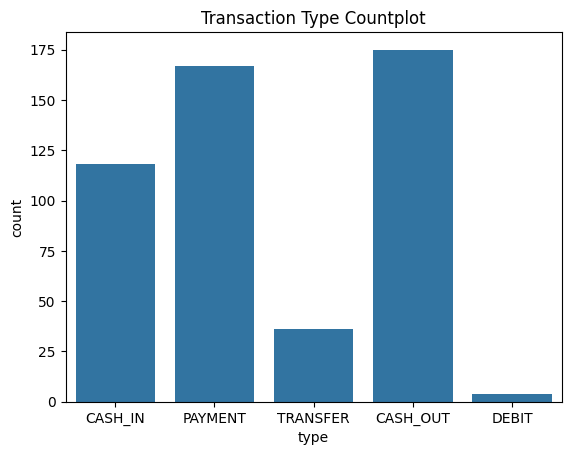

In [19]:
# Countplot - transaction type counts
sns.countplot(x='type', data=fraud_data)
plt.title('Transaction Type Countplot')
plt.show()

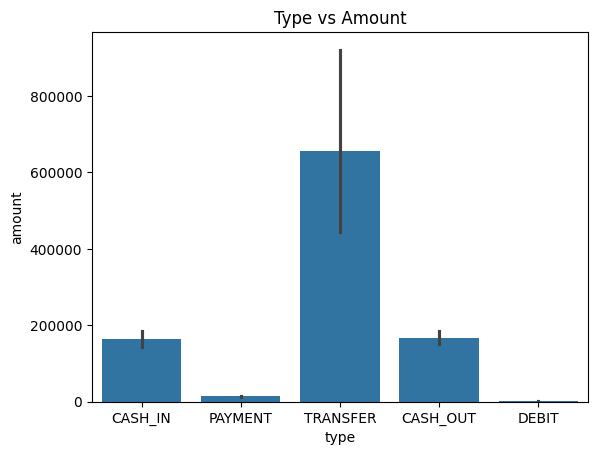

In [20]:
# Barplot - average amount by type
sns.barplot(x='type', y='amount', data=fraud_data)
plt.ticklabel_format(style='plain', axis='y')
plt.title('Type vs Amount')
plt.show()


isFraud
0    498
1      2
Name: count, dtype: int64


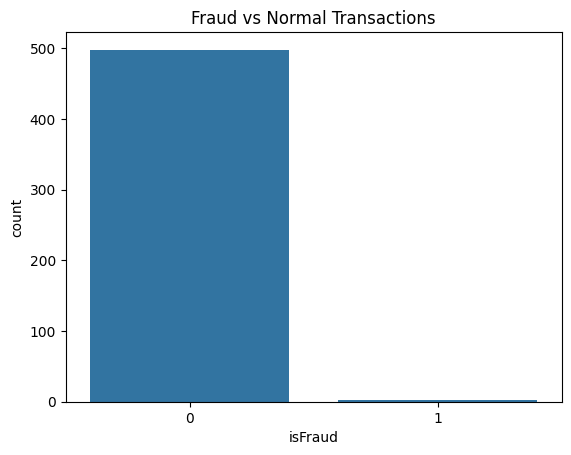

In [29]:
# isFraud value counts
print(fraud_data['isFraud'].value_counts())
sns.countplot(x='isFraud', data=fraud_data)
plt.title('Fraud vs Normal Transactions')
plt.show()

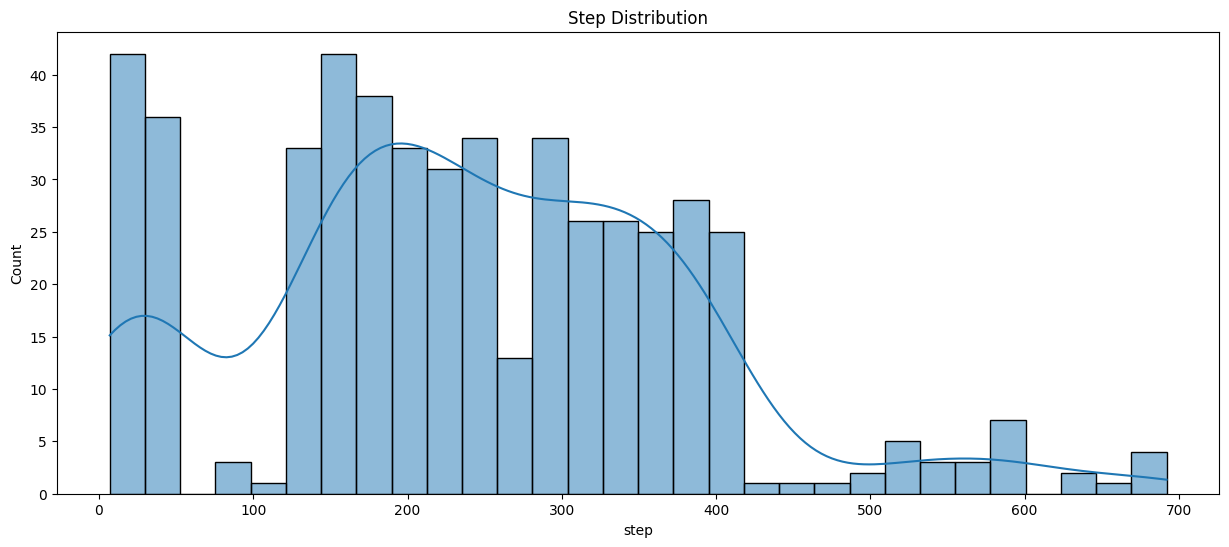

In [22]:
# Distribution of step (time)
plt.figure(figsize=(15, 6))
sns.histplot(fraud_data['step'], bins=30, kde=True)
plt.title('Step Distribution')
plt.show()

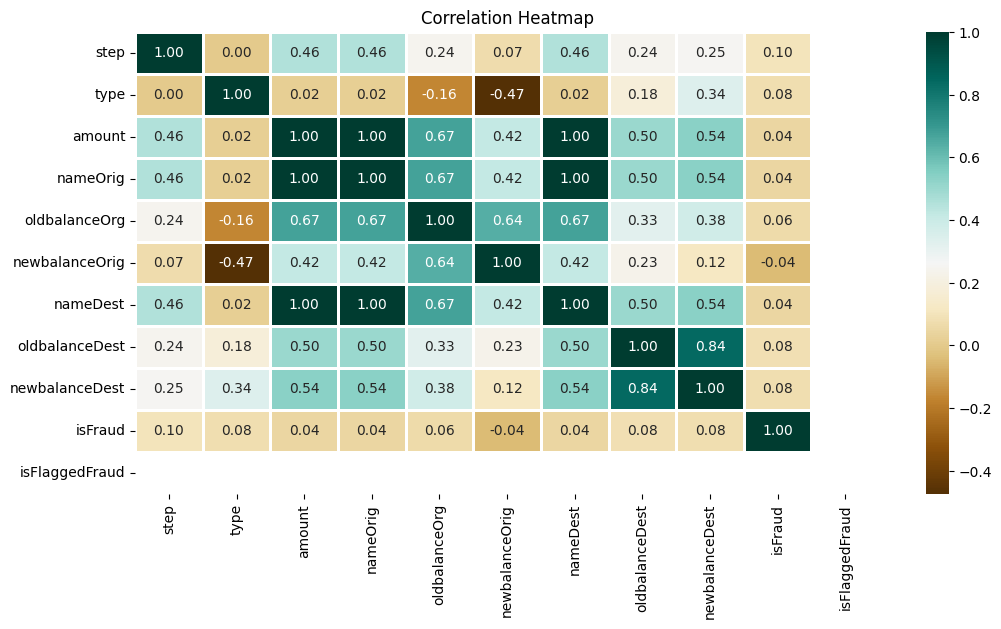

In [23]:
# Correlation heatmap
plt.figure(figsize=(12, 6))
corr_data = fraud_data.apply(lambda x: pd.factorize(x)[0])
sns.heatmap(corr_data.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [24]:
# ================================
# STEP 4: Data Preprocessing
# ================================
type_dummies = pd.get_dummies(fraud_data['type'], drop_first=True)
fraud_data_new = pd.concat([fraud_data, type_dummies], axis=1)

X = fraud_data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = fraud_data_new['isFraud']

print(X.shape, y.shape)

(500, 11) (500,)


In [25]:
# ================================
# STEP 5: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train: (350, 11) Test: (150, 11)
isFraud
0    349
1      1
Name: count, dtype: int64
isFraud
0    149
1      1
Name: count, dtype: int64


In [26]:
# ================================
# STEP 6: Model Training
# ================================
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'GradientBoosting': GradientBoostingClassifier(random_state=7),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_preds = model.predict_proba(X_train)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]
    print(f"{name}: Train AUC={ras(y_train, train_preds):.4f}, Test AUC={ras(y_test, test_preds):.4f}")


LogisticRegression: Train AUC=1.0000, Test AUC=0.9597
GradientBoosting: Train AUC=1.0000, Test AUC=0.5101
RandomForestClassifier: Train AUC=1.0000, Test AUC=0.5000


Confusion Matrix:
 [[149   0]
 [  1   0]]


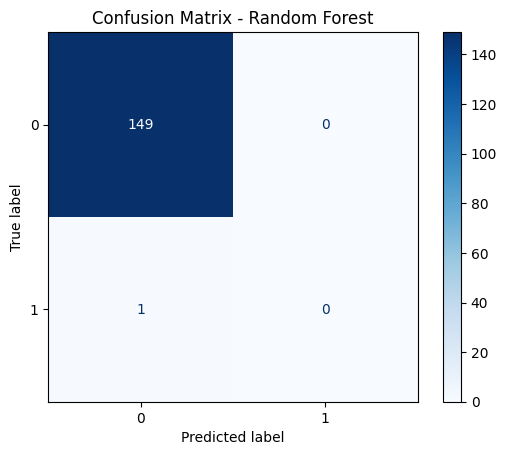

In [27]:
# ================================
# STEP 7: Model Evaluation - Confusion Matrix
# ================================
y_pred = models['RandomForestClassifier'].predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [28]:
# ================================
# STEP 8: Classification Report (Precision, Recall, F1)
# ================================
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       149
           1       0.00      0.00      0.00         1

    accuracy                           0.99       150
   macro avg       0.50      0.50      0.50       150
weighted avg       0.99      0.99      0.99       150

